# Regridding CMIP7 sea ice output

This notebook shows the two ways to regrid CMIP7 output, using monthly sea ice concentration from CanESM6-0-MR (`scen7-m`) regridded to the OSI SAF 25 km Northern Hemisphere grid:

1. **While loading**: pass `new_grid=` (and optionally `method=`) to `CMIP7(...)`.
2. **After loading**: load on the native grid, then call `regrid(ds, target_grid)` from `scripts/preprocessing/regrid.py`. This is useful when you also want the native-grid data, or want to try several target grids or methods without downloading again.

Both routes use the same `regrid()` function, so they give identical results. The notebook then plots the native and regridded fields, and checks how well sea ice area is conserved.

In [1]:
# Install these packages once per session on the cryohub.
# All packages are used by the loading code in scripts/data_access/load_cmip.py
# Skip if these packages are already installed in your environment

# ── Core climate/geospatial dependencies ──────────────────────────────────────
%pip install -q regionmask       # regional masking for geospatial data
%pip install -q bottleneck       # speeds up xarray reduce operations (rolling mean, etc.)
%pip install -q xesmf            # regridding for Earth System Model output
%pip install -q cf_xarray        # CF convention accessor for xarray datasets

# ── ESGF data access ──────────────────────────────────────────────────────────
%pip install -q intake-esgf      # intake driver for ESGF catalogs

# globus-sdk must stay below v4 until intake-esgf adds compatibility
%pip install -q "globus-sdk<4"

# pydantic upgrade needed for intake-esm compatibility
%pip install -q --upgrade intake-esm pydantic

# numpy pinned to <=2.3 due to numba incompatibility
%pip install -q "numpy<=2.3"

#colormaps
%pip install -q cmocean

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


**Restart the kernel after the installs above before running any further cells.**

## Setup

Imports the plotting packages and this repo's code from `scripts/`. The first lines add the repository root to `sys.path` (`REPO_ROOT`), so the cell works as long as `pyproject.toml` is in the root. The target grids are loaded from `data/ancillary/grids/` by `scripts/data_access/ancillary.py`.

In [1]:
import sys
from pathlib import Path

# make the repo's scripts/ importable
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import logging
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cm
from scripts.data_access.load_cmip import CMIP7, clear_esgf_cache
from scripts.data_access.ancillary import grid_OSISAF_nh
from scripts.preprocessing.regrid import regrid

Quiet the noisy Google Cloud and `urllib3` loggers. Other warnings (e.g. from `regrid`) still show.

In [2]:
# Quiet the noisy Google Cloud and urllib3 loggers
for name in logging.Logger.manager.loggerDict.keys():
    if ('google' in name) or ('url' in name):
        logger = logging.getLogger(name)
        logger.setLevel(logging.CRITICAL)
        logger.propagate = False  # Prevent propagation to root logger
        for handler in logger.handlers:  # Remove existing handlers
            logger.removeHandler(handler)

## Choose the model and target grid

Target grids available in `scripts/data_access/ancillary.py`:

| Grid | Description |
|---|---|
| `grid_OSISAF_nh`, `grid_OSISAF_sh` | OSI SAF EASE2 25 km grids (cells of 625 km²) |
| `grid_ATL20_nh`, `grid_ATL20_sh` | ICESat-2 / NSIDC 25 km polar stereographic grids |
| `grid_CESM2` | CESM2 global ocean grid (has `areacello`) |

Methods: `'conservative_normed'` (default; conserves area-weighted means, best for concentration, thickness and other fields you will sum or average), `'conservative'`, `'bilinear'`, or `'nearest_s2d'`. Unstructured-grid models (e.g. ICON-ESM-LR) always use `'nearest_s2d'`, and `tas`/`ts` always use `'bilinear'`; `regrid()` picks this automatically.

In [3]:
models = ['CanESM6-0-MR']
args = {'grid_label':'native', 'realm':'seaIce', 'frequency':'mon', 'experiment_id':'scen7-m', 'verbose':True}
target_grid = grid_OSISAF_nh
method = 'conservative_normed'

## Option 1: regrid while loading

With `new_grid=`, the loader attaches each model's cell corners, `areacello` and ocean mask, regrids it, and only then combines the models. The result is on the target grid's `y`/`x`, with the target's `lat`/`lon` and land `mask`.

`members='first'` loads one ensemble member; leave it out to load all of them. Files are downloaded from ESGF to `/tmp/esgf_manual` (see **Clean up**); a second load of the same data reuses them.

In [4]:
CMIP7_siconc_regrid_load = CMIP7(**args, variable='siconc', source_id=models, members='first',
                                 new_grid=target_grid, method=method).load_data()
CMIP7_siconc_regrid_load

['siconc'] available from: ['CanESM6-0-MR']


  0%|          | 0/1 [00:00<?, ?it/s]

Output()

Candidate ESGF URLs: 1
Using cached file: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r1i1p1f1/glb/mon/siconc/tavg-u-hxy-u/g147/v20260629/siconc_tavg-u-hxy-u_mon_glb_g147_CanESM6-0-MR_scen7-m_r1i1p1f1_202201-210012.nc
[CanESM6-0-MR] load_from_catalog returned 1 dataset(s) for siconc (grid=g147):
Using cached file: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/CMIP/CCCma/CanESM6-0-MR/1pctCO2/r1i1p1f1/glb/fx/areacello/ti-u-hxy-u/g147/v20260629/areacello_ti-u-hxy-u_fx_glb_g147_CanESM6-0-MR_1pctCO2_r1i1p1f1.nc
Using cached file: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/CMIP/CCCma/CanESM6-0-MR/1pctCO2/r1i1p1f1/glb/fx/sftof/ti-u-hxy-u/g147/v20260629/sftof_ti-u-hxy-u_fx_glb_g147_CanESM6-0-MR_1pctCO2_r1i1p1f1.nc
Concatenating 1 dataset(s), 1 member(s) total


<xarray.Dataset> Size: 1GB
Dimensions:        (y: 432, x: 432, experiment_id: 1, member_id: 1, time: 948)
Coordinates:
  * y              (y) float64 3kB 5.388e+03 5.362e+03 ... -5.362e+03 -5.388e+03
  * x              (x) float64 3kB -5.388e+03 -5.362e+03 ... 5.362e+03 5.388e+03
    mask           (y, x) int64 1MB 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0 0
    lat            (y, x) float32 746kB 16.62 16.82 17.02 ... 17.02 16.82 16.62
    lon            (y, x) float32 746kB -135.0 -135.1 -135.3 ... 44.87 45.0
  * experiment_id  (experiment_id) <U7 28B 'scen7-m'
  * member_id      (member_id) <U21 84B 'CanESM6-0-MR_r1i1p1f1'
    grid_label     (member_id) <U4 16B 'g147'
    native_grid    (member_id) bool 1B True
  * time           (time) datetime64[ns] 8kB 2022-01-16 ... 2100-12-16
Data variables:
    siconc         (experiment_id, member_id, time, y, x) float64 1GB dask.array<chunksize=(1, 1, 200, 432, 432), meta=np.ndarray>
Attributes:
    description:  regridded

## Option 2: regrid after loading

First load on the native grid. The loader attaches `areacello` (cell area, m²) and `mask` (ocean percentage, sftof) as coordinates.

In [5]:
CMIP7_siconc = CMIP7(**args, variable='siconc', source_id=models, members='first').load_data()
CMIP7_siconc

['siconc'] available from: ['CanESM6-0-MR']


  0%|          | 0/1 [00:00<?, ?it/s]

Output()

Candidate ESGF URLs: 1
Using cached file: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r1i1p1f1/glb/mon/siconc/tavg-u-hxy-u/g147/v20260629/siconc_tavg-u-hxy-u_mon_glb_g147_CanESM6-0-MR_scen7-m_r1i1p1f1_202201-210012.nc
[CanESM6-0-MR] load_from_catalog returned 1 dataset(s) for siconc (grid=g147):
Using cached file: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/CMIP/CCCma/CanESM6-0-MR/1pctCO2/r1i1p1f1/glb/fx/areacello/ti-u-hxy-u/g147/v20260629/areacello_ti-u-hxy-u_fx_glb_g147_CanESM6-0-MR_1pctCO2_r1i1p1f1.nc
Using cached file: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/CMIP/CCCma/CanESM6-0-MR/1pctCO2/r1i1p1f1/glb/fx/sftof/ti-u-hxy-u/g147/v20260629/sftof_ti-u-hxy-u_fx_glb_g147_CanESM6-0-MR_1pctCO2_r1i1p1f1.nc
Concatenating 1 dataset(s), 1 member(s) total


<xarray.Dataset> Size: 455MB
Dimensions:        (experiment_id: 1, member_id: 1, y: 331, x: 360, time: 948)
Coordinates:
  * experiment_id  (experiment_id) <U7 28B 'scen7-m'
  * member_id      (member_id) <U21 84B 'CanESM6-0-MR_r1i1p1f1'
    grid_label     (member_id) <U4 16B 'g147'
    native_grid    (member_id) bool 1B True
  * y              (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
  * x              (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
    lat            (y, x) float64 953kB -84.21 -84.21 -84.21 ... 50.23 50.01
    lon            (y, x) float64 953kB 73.5 74.5 75.5 ... 72.95 72.96 72.99
    areacello      (y, x) float32 477kB nan nan nan nan nan ... nan nan nan nan
    mask           (y, x) float32 477kB ...
  * time           (time) datetime64[ns] 8kB 2022-01-16 ... 2100-12-16
Data variables:
    siconc         (experiment_id, member_id, time, y, x) float32 452MB dask.array<chunksize=(1, 1, 200, 331, 360), meta=np.ndarray>
Attributes:
    description:  No spatial subsetting or regridding

Then regrid. `regrid()` takes a Dataset or DataArray and:
1. checks for `mask` and `areacello`, warning if either is missing (the mask, rescaled from % to a 0–1 fraction, tells xESMF which source cells are ocean);
2. builds the cell corners (`add_corners`) needed for conservative regridding, so there is no need to call it yourself;
3. regrids with xESMF and masks the result to the target grid's land `mask`.

The output carries the target grid's corners (`lon_b`/`lat_b`), so it can be regridded again.

**Regrid one model at a time.** Without `new_grid`, `load_data()` combines models on different native grids, so a multi-model native Dataset can't be regridded in one go. For several models, either use Option 1 or loop over them:

```python
regridded = xr.concat([regrid(CMIP7(**args, variable='siconc', source_id=sid, members='first').load_data(), target_grid)
                       for sid in models], 'member_id')
```

In [6]:
CMIP7_siconc_regrid = regrid(CMIP7_siconc, target_grid, method=method)
CMIP7_siconc_regrid

<xarray.Dataset> Size: 1GB
Dimensions:        (experiment_id: 1, member_id: 1, time: 948, y: 432, x: 432,
                    y_b: 433, x_b: 433)
Coordinates:
  * experiment_id  (experiment_id) <U7 28B 'scen7-m'
  * member_id      (member_id) <U21 84B 'CanESM6-0-MR_r1i1p1f1'
    grid_label     (member_id) <U4 16B 'g147'
    native_grid    (member_id) bool 1B True
  * time           (time) datetime64[ns] 8kB 2022-01-16 ... 2100-12-16
  * y              (y) float64 3kB 5.388e+03 5.362e+03 ... -5.362e+03 -5.388e+03
  * x              (x) float64 3kB -5.388e+03 -5.362e+03 ... 5.362e+03 5.388e+03
    lat            (y, x) float32 746kB 16.62 16.82 17.02 ... 17.02 16.82 16.62
    lon            (y, x) float32 746kB -135.0 -135.1 -135.3 ... 44.87 45.0
    mask           (y, x) int64 1MB 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0 0
    lon_b          (y_b, x_b) float32 750kB -135.0 -135.1 -135.3 ... 44.87 45.0
    lat_b          (y_b, x_b) float32 750kB 16.43 16.62 16.82 ... 16.62 16.43
Dimensions without coordinates: y_b, x_b
Data variables:
    siconc         (experiment_id, member_id, time, y, x) float64 1GB dask.array<chunksize=(1, 1, 200, 432, 432), meta=np.ndarray>
Attributes:
    regrid_method:  conservative_normed

## Compare

The two options give the same result:

In [7]:
date = '2026-09'
a = CMIP7_siconc_regrid_load.siconc.sel(time=date)
b = CMIP7_siconc_regrid.siconc.sel(time=date)
print('max abs difference (%):', float(np.abs(a - b).max()))

max abs difference (%): 0.0


### Figures

September 2026 sea ice concentration on the native grid and after each route.

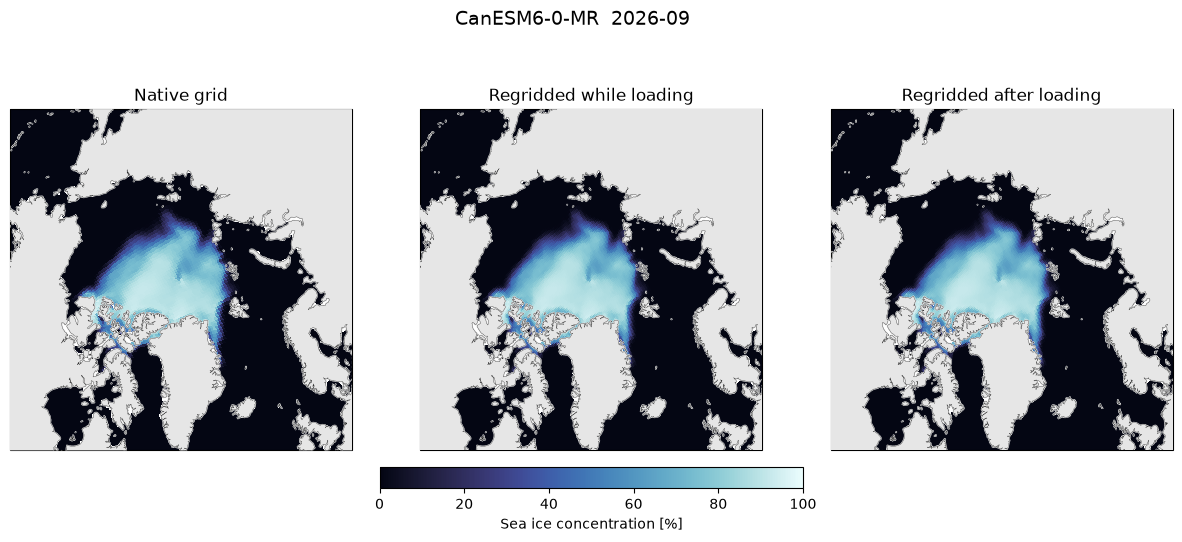

In [8]:
fields = [CMIP7_siconc.siconc.sel(time=date).squeeze(),
          CMIP7_siconc_regrid_load.siconc.sel(time=date).squeeze(),
          CMIP7_siconc_regrid.siconc.sel(time=date).squeeze()]
titles = ['Native grid', 'Regridded while loading', 'Regridded after loading']

fig, axs = plt.subplots(1, 3, figsize=(15, 5.5), subplot_kw={'projection': ccrs.LambertAzimuthalEqualArea(-45, 90)})
for ax, da, title in zip(axs, fields, titles):
    p = ax.pcolormesh(da.lon, da.lat, da, vmin=0, vmax=100, cmap=cm.cm.ice,
                      transform=ccrs.PlateCarree(), shading='auto', rasterized=True)
    ax.add_feature(cfeature.LAND, color='0.9', zorder=5)
    ax.coastlines(resolution='50m', linewidth=0.2, zorder=6)
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.set_title(title)
fig.colorbar(p, ax=axs, orientation='horizontal', fraction=0.05, pad=0.04, label='Sea ice concentration [%]')
fig.suptitle(f'{models[0]}  {date}', fontsize=14);

### Sea ice area

Conservative regridding should keep the Northern Hemisphere sea ice area close to the native value: Σ(concentration × cell area), in 10$^6$ km$^2$. The native grid uses the model's grid cell area (`areacello`). OSI SAF has no `areacello`, but its EASE2 cells are all 625 km$^2$. The regridded area is a little lower, by a roughly fixed amount (a few hundredths of 10$^6$ km$^2$): likely due to differences in ocean masks.

mean difference: -0.031 million km2
mean relative difference while native area > 1 million km2$: -2.6%


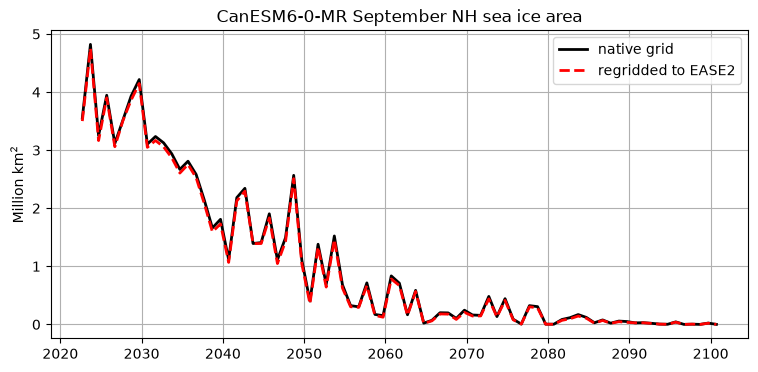

In [10]:
cell_area = target_grid.areacello if 'areacello' in target_grid else 625e6  # m2; EASE2 25 km cells are 625 km2

sep = lambda ds: ds.siconc.where(ds.time.dt.month == 9, drop=True).squeeze()
native = sep(CMIP7_siconc)
sia_native = (native / 100 * CMIP7_siconc.areacello).where(native.lat > 0).sum(['x', 'y']) * 1e-12
sia_regrid = (sep(CMIP7_siconc_regrid) / 100 * cell_area).sum(['x', 'y']) * 1e-12

fig, ax = plt.subplots(figsize=(9, 4))
sia_native.plot(ax=ax, c='k', label='native grid',lw=2)
sia_regrid.plot(ax=ax, c='r', label='regridded to EASE2', ls='--',lw=2)
ax.set_ylabel('Million km$^{2}$'); ax.set_xlabel(''); ax.set_title(f'{models[0]} September NH sea ice area')
ax.legend(); ax.grid()
diff = sia_regrid - sia_native
print(f'mean difference: {float(diff.mean()):.3f} million km2')
print(f'mean relative difference while native area > 1 million km2$: {float((diff / sia_native).where(sia_native > 1).mean()) * 100:.1f}%')

## Clean up

Raw ESGF downloads are kept in `/tmp/esgf_manual`, where space is limited. Set `clear_cache=True` to delete them once you have saved what you need. Datasets loaded before clearing still point at the deleted files, so re-run their load cells before using them again.

In [16]:
clear_cache=False

In [17]:
# Free /tmp space used by the raw ESGF downloads
if clear_cache==True:
    clear_esgf_cache()